In [1]:
## Standard libraries ====
import os
import random
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

## Visualization ====
import logomaker
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

## PyTorch and Machine learning ====
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

## Utilities ====
from util import getPFM, Motif2Seqs, sci_ticks

In [2]:
## Set random seed for reproducibility
def set_seed(seed):
    """Set seed for reproducibility across libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # If using GPUs:
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # For deterministic operations (optional, can slow things down):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Set seed
SEED = 777
set_seed(SEED)

## Determine if a GPU is available and select the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## TensorBoard setup instructions (can be uncommented in a notebook)
%load_ext tensorboard
%tensorboard --logdir=runs --port=5678

Using device: cuda


Reusing TensorBoard on port 5678 (pid 59900), started 2:20:16 ago. (Use '!kill 59900' to kill it.)

In [3]:
def stratified_sample(df, col, counts, seed=SEED):
    """
    Performs stratified sampling by extracting a specified number of samples from each bin of a column in the dataframe.
    The column is divided into bins, and a defined number of samples is taken from each bin.

    Args:
        df (pd.DataFrame): The input dataframe.
        col (str): The column used for creating bins, which serves as the basis for stratification.
        counts (list): Number of samples to extract from each bin, corresponding to each created bin.
        seed (int): Random seed for reproducibility.

    Returns:
        pd.DataFrame: Dataframe containing the extracted stratified samples.
    """
    np.random.seed(seed)
    df['grp'] = pd.cut(df[col], bins=len(counts))
    extracted = pd.concat(
        df[df['grp'] == grp].sample(cnt, replace=True, random_state=seed)
        for grp, cnt in zip(sorted(df['grp'].unique()), counts)
        )
    return extracted.drop(columns=['grp'])

In [4]:
def dna_one_hot(seq, flatten=False):
    """
    Convert a DNA sequence to its one-hot encoded binary representation.

    Parameters:
        seq (str): The DNA sequence to convert, consisting of characters 'A', 'C', 'G', 'T', or '-'.
        flatten (bool): Whether to return the array in a flattened form (default is False).
    
    Returns:
        np.ndarray: A numpy array of one-hot encoded binary arrays representing the DNA sequence.
                    Each base is represented by a binary array of length 4, where only one element is 1 (indicating the base) and all others are 0.
                    The character '-' is represented by an array of all zeros. If flatten is True, the array will be flattened to a 1D array.
    """
    mapping = {'A': [1, 0, 0, 0], 'C': [0, 1, 0, 0], 'G': [0, 0, 1, 0], 'T': [0, 0, 0, 1], '-': [-1, -1, -1, -1], 'N': [1/4, 1/4, 1/4, 1/4]}
    one_hot = np.array([mapping.get(base, [0, 0, 0, 0]) for base in seq.upper()]).T
    return one_hot.flatten() if flatten else one_hot

In [5]:
## Data Sampling
## ========================================
def PpurR(seq):
    # return 'TTCGTCTTCACACAGCAGCAGTCAGGTACTCCAGTCCAC'+seq[:6]+'TTTTCGTCAAGATCGGC'+seq[-6:]+'TCCACGCTTACTAAATCTATGTAGCTGTCACC' # 100 bp
    return 'CACAGCAGCAGTCAGGTACTCCAGTCCAC'+seq[:6]+'TTTTCGTCAAGATCGGC'+seq[-6:]+'TCCACGCTTACTAAATCTATGT' # 80 bp
    # return 'CACAGCANNNNNNNNNNNNNNNNNNNCAC'+seq[:6]+'TTTTCGTCAAGATCGGC'+seq[-6:]+'TCCACGCTTACTAAATCTATGT' # 80 bp
    # return 'CACAGCAGCAGTCAGGTACTCCAGTCCAC'+seq[:6]+'TTTTCGTCAAGATCGGC'+seq[-6:]+'TCCACGCTTACT' # 70 bp
    # return 'CACAGCANNNNNNNNNNNNNNNNNNNCAC'+seq[:6]+'TTTTCGTCAAGATCGGC'+seq[-6:]+'TCCACGCTTACT' # 70 bp

def SL16(seq):
    # return 'TCGTCTTCACACAGCAGCAGTCAGGTACTCCAGTAAATGCTTGACT'+seq+'TATTATGCACACCCCTAAATCTATGTAGCTGTCACCGG' # 100 bp
    return 'ACAGCAGCAGTCAGGTACTCCAGTAAATGCTTGACT'+seq+'TATTATGCACACCCCTAAATCTATGTAG' # 80 bp
    # return 'ACAGCAGNNNNNNNNNNNNNNNNNNNNTGCTTGACT'+seq+'TATTATGCACACCCCTAAATCTATGTAG' # 80 bp
    # return 'ACAGCAGCAGTCAGGTACTCCAGTAAATGCTTGACT'+seq+'TATTATGCACACCCCTAA' # 70 bp
    # return 'ACAGCAGNNNNNNNNNNNNNNNNNNNNTGCTTGACT'+seq+'TATTATGCACACCCCTAA' # 70 bp

def SL17(seq):
    # return 'TTCGTCTTCACACAGCAGCAGTCAGGTACTCCAGTCCACTTGACC'+seq+'TAACCTTCCACGCTTACTAAATCTATGTAGCTGTCACC' # 100 bp
    return 'CACAGCAGCAGTCAGGTACTCCAGTCCACTTGACC'+seq+'TAACCTTCCACGCTTACTAAATCTATGT' # 80 bp
    # return 'CACAGCANNNNNNNNNNNNNNNNNNNCACTTGACC'+seq+'TAACCTTCCACGCTTACTAAATCTATGT' # 80 bp
    # return 'CACAGCAGCAGTCAGGTACTCCAGTCCACTTGACC'+seq+'TAACCTTCCACGCTTACT' # 70 bp
    # return 'CACAGCANNNNNNNNNNNNNNNNNNNCACTTGACC'+seq+'TAACCTTCCACGCTTACT' # 70 bp

def SL18(seq):
    # return 'GGCCCTTTCGTCTTCACACAGCAGCTCAGGTACTCAGGCTTTACA'+seq+'GATAATGTGTGGAATTAAATCTATGTAGCTGTCACCG' # 100 bp
    return 'TCTTCACACAGCAGCTCAGGTACTCAGGCTTTACA'+seq+'GATAATGTGTGGAATTAAATCTATGTA' # 80 bp
    # return 'TCTTCACNNNNNNNNNNNNNNNNNNNGGCTTTACA'+seq+'GATAATGTGTGGAATTAAATCTATGTA' # 80 bp
    # return 'TCTTCACACAGCAGCTCAGGTACTCAGGCTTTACA'+seq+'GATAATGTGTGGAATTA' # 70 bp
    # return 'TCTTCACNNNNNNNNNNNNNNNNNNNGGCTTTACA'+seq+'GATAATGTGTGGAATTA' # 70 bp

def DL(seq):
    # return 'GTCTTCACACAGCAGCAGTCAGGTACTCCAGTAAATGCTTGCCCGCCGCGTGATTCGTGTTATAAC'+seq+'CAAAATCTATGTAGCTGTCACCGGAT' # 100 bp
    return 'AGCAGCAGTCAGGTACTCCAGTAAATGCTTGCCCGCCGCGTGATTCGTGTTATAAC'+seq+'CAAAATCTATGTAGCT' # 80 bp
    # return 'AGCAGCNNNNNNNNNNNNNNNNNNNTGCTTGCCCGCCGCGTGATTCGTGTTATAAC'+seq+'CAAAATCTATGTAGCT' # 80 bp
    # return 'AGCAGCAGTCAGGTACTCCAGTAAATGCTTGCCCGCCGCGTGATTCGTGTTATAAC'+seq+'CAAAAT' # 70 bp
    # return 'AGCAGCNNNNNNNNNNNNNNNNNNNTGCTTGCCCGCCGCGTGATTCGTGTTATAAC'+seq+'CAAAAT' # 70 bp

def UL(seq):
    # return 'ACAGGGCAGGCAGAAAAAG'+seq+'GGCTTGCGGCTTTTGCCGCTTTTTTTTACCCTGCACACCCCTAAATCTATGTAGCTGTCACC' # 100 bp
    # return 'CAGAAAAAG'+seq+'GGCTTGCGGCTTTTGCCGCTTTTTTTTACCCTGCACACCCCTAAATCTATGT' # 80 bp
    return 'CAGAAAAAG'+seq+'GGCTTGCGGCTTTTGCCGCTTTTTTTTACCCTGCACACCCCT----------' # 80 bp
    # return 'CAGAAAAAG'+seq+'GGCTTGCGGCTTTTGCCGCTTTTTTTTACCCTGCACACCCCT' # 70 bp

## ========================================
df_PL17 = stratified_sample(pd.read_pickle("../tables/PL_Con17_scanning.pkl"), 'LogGFP', [2000, 2000, 2000, 1000, 1000, 1000, 500, 500])[['rep1', 'rep2', 'LogGFP']]
df_PL17['Sequence'] = df_PL17.index.map(PpurR)
df_PL17['Library'] = "PL17"

df_SL16 = stratified_sample(pd.read_pickle("../tables/SL16.pkl"), 'LogGFP', [300]*10)[['rep1', 'rep2', 'LogGFP']]
df_SL16['Sequence'] = df_SL16.index.map(SL16)
df_SL16['Library'] = "SL16"

df_SL17 = stratified_sample(pd.read_pickle("../tables/SL17.pkl"), 'LogGFP', [400]*10)[['rep1', 'rep2', 'LogGFP']]
df_SL17['Sequence'] = df_SL17.index.map(SL17)
df_SL17['Library'] = "SL17"

df_SL18 = stratified_sample(pd.read_pickle("../tables/SL18.pkl"), 'LogGFP', [300]*10)[['rep1', 'rep2', 'LogGFP']]
df_SL18['Sequence'] = df_SL18.index.map(SL18)
df_SL18['Library'] = "SL18"

df_DL = stratified_sample(pd.read_pickle("../tables/DL.pkl"), 'LogGFP', [200]*10)[['rep1', 'rep2', 'LogGFP']]
df_DL['Sequence'] = df_DL.index.map(DL)
df_DL['Library'] = "DL"

df_UL = pd.read_pickle("../tables/UL.pkl")
df_UL = df_UL[(df_UL['LogGFP']>1) & (df_UL['LogGFP']<4)]
df_UL = stratified_sample(df_UL, 'LogGFP', [500, 1000, 1500, 1500, 1000, 500])[['rep1', 'rep2', 'LogGFP']]
df_UL['Sequence'] = df_UL.index.map(UL)
df_UL['Library'] = "UL"

df_train = pd.concat([df_PL17, df_SL16, df_SL17, df_SL18, df_DL, df_UL]).reset_index(drop=True)
df_train

## ========================================
# df_UL = pd.read_pickle("../tables/UL.pkl")
# df_UL = df_UL[(df_UL['LogGFP']>1.4) & (df_UL['LogGFP']<2.6)]
# df_UL = stratified_sample(df_UL, 'LogGFP', [500, 1000, 1500, 1500, 1000, 500])[['rep1', 'rep2', 'LogGFP']]
# df_UL['Sequence'] = df_UL.index
# df_UL['Library'] = "UL"

# df_train = pd.concat([df_UL]).reset_index(drop=True)
# df_train

,rep1,rep2,LogGFP,Sequence,Library
0,0.446169,0.409302,0.427736,CACAGCAGCAGTCAGGTACTCCAGTCCACACATATTTTTCGTCAAG...,PL17
1,0.622179,0.467092,0.544635,CACAGCAGCAGTCAGGTACTCCAGTCCACGGAACATTTTCGTCAAG...,PL17
2,0.502947,NaN,0.502947,CACAGCAGCAGTCAGGTACTCCAGTCCACATATGTTTTTCGTCAAG...,PL17
3,0.664487,0.406002,0.535245,CACAGCAGCAGTCAGGTACTCCAGTCCACATAAGATTTTCGTCAAG...,PL17
4,0.545845,NaN,0.545845,CACAGCAGCAGTCAGGTACTCCAGTCCACGTTAGGTTTTCGTCAAG...,PL17
...,...,...,...,...,...
27995,2.965819,3.031932,2.998876,CAGAAAAAGACTCGATCTTGGTAATTAAGGCTTGCGGCTTTTGCCG...,UL
27996,2.965819,3.031932,2.998876,CAGAAAAAGACTCGATCTTGGTAATTAAGGCTTGCGGCTTTTGCCG...,UL
27997,2.504497,3.045250,2.774873,CAGAAAAAGCCAAAACAGATGGGATTTAGGCTTGCGGCTTTTGCCG...,UL
27998,2.694453,3.044327,2.869390,CAGAAAAAGCTTTATAGGTGTAATTTAGGGCTTGCGGCTTTTGCCG...,UL


In [6]:
class DNAFunctionPredictor(nn.Module):
    def __init__(self, seq_length, num_conds):
        super(DNAFunctionPredictor, self).__init__()
        self.seq_length = seq_length
        
        ## Define layers and condition biases
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=6, kernel_size=9, stride=1)
        self._initialize_conv1()
        
        self.conv2 = nn.Conv1d(in_channels=6, out_channels=3, kernel_size=52, stride=1)
        self._initialize_conv2()
        
        self.conds_bias = nn.Parameter(torch.zeros(6))
        
        ## Define custom trainable parameters for self-defined function
        self.param_max = nn.Parameter(torch.tensor(np.log(1000)), requires_grad=True)
        self.param_min = nn.Parameter(torch.tensor(np.log(0.5)), requires_grad=True)
        self.param_e0 = nn.Parameter(torch.tensor(0.0), requires_grad=True)
        
        # ## Fully connected layers
        # self.fc1 = nn.Linear(num_conds + 1, 8)  # Adjust input size
        # self.fc2 = nn.Linear(8, 8)
        # self.fc3 = nn.Linear(8, 1)  # Output a single value
        
    def _initialize_conv1(self):
        ## Define custom motifs for each filter
        motif1 = getPFM(Motif2Seqs("AAAAAATTT"), ratios=True).values.T  # Shape: (4, 9)
        motif2 = getPFM(Motif2Seqs("GGAAAATAG"), ratios=True).values.T  # Shape: (4, 9)
        motif3 = getPFM(Motif2Seqs("CTTGACATT"), ratios=True).values.T  # Shape: (4, 9)
        motif4 = getPFM(Motif2Seqs("GGCCTAAAT"), ratios=True).values.T  # Shape: (4, 9)
        motif5 = getPFM(Motif2Seqs("GGGGTATAA"), ratios=True).values.T  # Shape: (4, 9)
        motif6 = getPFM(Motif2Seqs("TTTTTAAAG"), ratios=True).values.T  # Shape: (4, 9)
    
        # ## Combine into a single array for one filter
        # filter1_weights = np.concatenate([np.zeros((4, 15)), motif1, np.zeros((4, 3))], axis=1)
        # filter2_weights = np.concatenate([np.zeros((4, 13)), motif2, np.zeros((4, 8))], axis=1)
        
        ## Stack filters to form the weight tensor (out_channels, in_channels, kernel_size)
        custom_weights = np.stack([motif1, motif2, motif3, motif4, motif5, motif6], axis=0)
        weight_tensor = torch.tensor(custom_weights, dtype=torch.float32)
        self.conv1.weight = nn.Parameter(weight_tensor, requires_grad=True)
        
        self.conv1.bias.data.zero_()
        self.conv1.bias.requires_grad = False

        # ## ==== Register hook to zero gradients at positions 15-18 (Python slice excludes 18) ====
        # def hook_fn(grad):
        #     mask = torch.ones_like(grad)
        #     mask[0, :, 15:18] = 0 # Zero out filter1's positions 15, 16, 17 (3 positions, channel=0)
        #     return grad * mask
    
        # self.conv1.weight.register_hook(hook_fn)

    def _initialize_conv2(self):    
        ## Define the weights directly using numpy
        filter1_weights = np.zeros((6, 52))
        filter2_weights = np.zeros((6, 52))
        filter3_weights = np.zeros((6, 52))
        
        filter1_weights[0, 1], filter1_weights[1, 10], filter1_weights[2, 21], filter1_weights[3, 31], filter1_weights[4, 40], filter1_weights[5, 49] = 1, 1, 1, 1, 1, 1
        filter2_weights[0, 1], filter2_weights[1, 10], filter2_weights[2, 21], filter2_weights[3, 32], filter2_weights[4, 41], filter2_weights[5, 50] = 1, 1, 1, 1, 1, 1
        filter3_weights[0, 1], filter3_weights[1, 10], filter3_weights[2, 21], filter3_weights[3, 33], filter3_weights[4, 42], filter3_weights[5, 51] = 1, 1, 1, 1, 1, 1
        
        ## Stack filters to form the weight tensor (out_channels, in_channels, kernel_size)
        custom_weights = np.stack([filter1_weights, filter2_weights, filter3_weights], axis=0)
        
        ## Assign the custom weights to the layer
        self.conv2.weight.data = torch.tensor(custom_weights, dtype=torch.float32)
        self.conv2.weight.requires_grad = False
        
        ## Set the biases to zero
        self.conv2.bias.data.zero_()
        self.conv2.bias.requires_grad = True

    def energy(self, dna_seq):
        """
        Process the DNA sequence through Conv1D and apply global max pooling.
        :param dna_seq: DNA sequence (batch_size, 4, seq_length)
        :return: Processed sequence features (batch_size, 1)
        """
        x = self.conv1(dna_seq)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)  # Remove the channel dimension
        x = F.max_pool1d(x, kernel_size=x.size(-1))  # Global max pooling
        return x

    def energy2expression(self, x):
        """
        Custom function with Boltzmann weight and logarithmic transformation.
        :param x: Input tensor (batch_size, num_features)
        :return: Transformed tensor based on the custom formula.
        """
        ## Calculate Boltzmann weight
        beta = 1/(0.001987*310) # 1/(kB*T) ~ 1.6234
        BoltzWeight = torch.exp(beta * (x + self.param_e0))
        
        ## Exponentiate trainable parameters for Max and Min
        Max = torch.exp(self.param_max)
        Min = torch.exp(self.param_min)
        
        ## Custom expression
        expression = torch.log(Min + Max * (BoltzWeight) / (1+BoltzWeight))
        
        return expression
        
    def forward(self, dna_seq, conds):
        """
        Forward pass for the model.
        :param dna_seq: DNA sequence (batch_size, 4, seq_length)
        :param conds: One-hot encoded experimental conditions (batch_size, num_conds)
        """
        ## Process the DNA sequence
        x = self.energy(dna_seq)  # (batch_size, 1)
        x += torch.matmul(conds, self.conds_bias.unsqueeze(1))
        
        ## Pass through the self-defined function
        output = self.energy2expression(x)
        
        # ## Concatenate with batch one-hot
        # x = torch.cat((x, conds), dim=1)
        
        # ## Fully connected layers
        # x = F.sigmoid(self.fc1(x))
        # x = F.sigmoid(self.fc2(x))
        # output = self.fc3(x)  # Single value output
        
        return output

## Training ====

In [7]:
## Data Preparation
## =======================
## Convert DNA sequences to one-hot encoding and prepare conditions
dna_seq = np.array(list(df_train['Sequence'].apply(dna_one_hot)))  # (batch_size, 4, seq_length)
dan_func = df_train['LogGFP'].values * np.log(10)  # Target values for regression
conds = np.vstack([
    np.repeat([[1, 0, 0, 0, 0, 0]], 10000, axis=0),
    np.repeat([[0, 1, 0, 0, 0, 0]], 3000, axis=0),
    np.repeat([[0, 0, 1, 0, 0, 0]], 4000, axis=0),
    np.repeat([[0, 0, 0, 1, 0, 0]], 3000, axis=0),
    np.repeat([[0, 0, 0, 0, 1, 0]], 2000, axis=0),
    np.repeat([[0, 0, 0, 0, 0, 1]], 6000, axis=0),
    ])

## Split data into training and testing sets
TEST_SIZE = 0.2
X_train_seq, X_test_seq, X_train_conds, X_test_conds, y_train, y_test = train_test_split(
    dna_seq, conds, dan_func, test_size=TEST_SIZE, random_state=42
    )

## Convert data to PyTorch tensors and move to device
X_train_seq = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
X_train_conds = torch.tensor(X_train_conds, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

X_test_seq = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
X_test_conds = torch.tensor(X_test_conds, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

## Create DataLoaders for batching
BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_seq, X_train_conds, y_train)
test_dataset = TensorDataset(X_test_seq, X_test_conds, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
# Model Initialization
# =======================
seq_length = dna_seq.shape[2]  # Sequence length
num_conds = conds.shape[1]  # Number of experimental conditions

model = DNAFunctionPredictor(seq_length=seq_length, num_conds=num_conds).to(device)

# Optimizer and Loss Function
# =======================
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # L2 regularization

# TensorBoard Setup
# =======================
TENSORBOARD_LOG_DIR = "runs/20250628_CorePromoter_v0"
writer = SummaryWriter(TENSORBOARD_LOG_DIR)

# Training Loop
# =======================
EPOCHS = 50
for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    for seq_batch, cond_batch, target_batch in train_loader:
        # Move batches to device
        seq_batch, cond_batch, target_batch = seq_batch.to(device), cond_batch.to(device), target_batch.to(device)
        
        # Forward pass and optimization
        optimizer.zero_grad()
        output = model(seq_batch, cond_batch)
        loss = criterion(output, target_batch)
        loss.backward()
        optimizer.step()

    # Evaluation Phase
    model.eval()
    with torch.no_grad():
        # Evaluate on training set
        train_loss = criterion(model(X_train_seq, X_train_conds)/np.log(10), y_train/np.log(10))
        # Evaluate on testing set
        test_loss = criterion(model(X_test_seq, X_test_conds)/np.log(10), y_test/np.log(10))

    # Log results
    print(f"Epoch [{(epoch+1):02d}/{EPOCHS}] - Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}")
    writer.add_scalars('Loss', {'Training Loss': train_loss.item(), 'Testing Loss': test_loss.item()}, epoch+1)

# Close TensorBoard Writer
writer.close()

Epoch [01/50] - Train Loss: 0.3201, Test Loss: 0.3076
Epoch [02/50] - Train Loss: 0.2332, Test Loss: 0.2328
Epoch [03/50] - Train Loss: 0.2074, Test Loss: 0.2098
Epoch [04/50] - Train Loss: 0.1839, Test Loss: 0.1833
Epoch [05/50] - Train Loss: 0.1704, Test Loss: 0.1696
Epoch [06/50] - Train Loss: 0.1636, Test Loss: 0.1632
Epoch [07/50] - Train Loss: 0.1565, Test Loss: 0.1570
Epoch [08/50] - Train Loss: 0.1527, Test Loss: 0.1531
Epoch [09/50] - Train Loss: 0.1473, Test Loss: 0.1479
Epoch [10/50] - Train Loss: 0.1447, Test Loss: 0.1448
Epoch [11/50] - Train Loss: 0.1423, Test Loss: 0.1425
Epoch [12/50] - Train Loss: 0.1401, Test Loss: 0.1399
Epoch [13/50] - Train Loss: 0.1384, Test Loss: 0.1381
Epoch [14/50] - Train Loss: 0.1382, Test Loss: 0.1375
Epoch [15/50] - Train Loss: 0.1381, Test Loss: 0.1370
Epoch [16/50] - Train Loss: 0.1378, Test Loss: 0.1370
Epoch [17/50] - Train Loss: 0.1348, Test Loss: 0.1343
Epoch [18/50] - Train Loss: 0.1370, Test Loss: 0.1361
Epoch [19/50] - Train Loss: 

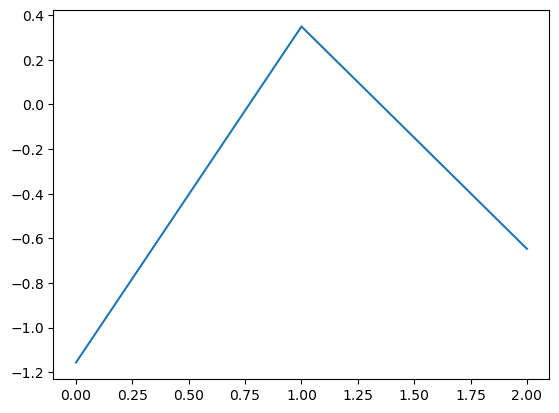

In [9]:
plt.plot(model.conv2.bias.cpu().detach().numpy())

In [10]:
model.conds_bias.cpu().detach().numpy()

array([-0.25836992, -0.45635074,  0.25765005, -0.9383913 , -1.186813  ,
        0.558583  ], dtype=float32)

## Show Conv1d Layer ====

In [11]:
def ShowLogo(ax, pwm):
    ## custom color scheme
    color_scheme = {
        'A' : 'green',
        'C' : 'blue',
        'G' : 'orange',
        'T' : 'red',
        u'АСᏀТ': '#dfdfdf'
        }

    ## plot the Logo
    pwm_logo = logomaker.Logo(pwm,
                              shade_below=.6,
                              fade_below=.6,
                              font_name='DejaVu Sans',
                              color_scheme=color_scheme,
                              ax=ax)
    
    return None

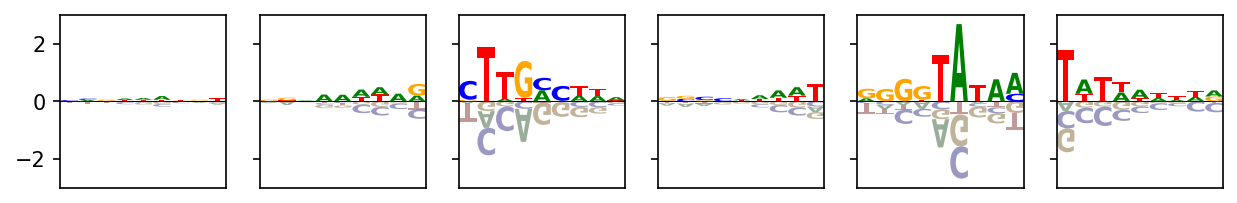

In [67]:
df_motif1 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[0]).T, columns=['A', 'C', 'G', 'T'])
df_motif1 = df_motif1.sub(df_motif1.mean(axis=1), axis=0)  # Center each row
df_motif2 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[1]).T, columns=['A', 'C', 'G', 'T'])
df_motif2 = df_motif2.sub(df_motif2.mean(axis=1), axis=0)  # Center each row
df_motif3 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[2]).T, columns=['A', 'C', 'G', 'T'])
df_motif3 = df_motif3.sub(df_motif3.mean(axis=1), axis=0)  # Center each row
df_motif4 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[3]).T, columns=['A', 'C', 'G', 'T'])
df_motif4 = df_motif4.sub(df_motif4.mean(axis=1), axis=0)  # Center each row
df_motif5 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[4]).T, columns=['A', 'C', 'G', 'T'])
df_motif5 = df_motif5.sub(df_motif5.mean(axis=1), axis=0)  # Center each row
df_motif6 = pd.DataFrame(np.array(model.conv1.weight.data.cpu()[5]).T, columns=['A', 'C', 'G', 'T'])
df_motif6 = df_motif6.sub(df_motif6.mean(axis=1), axis=0)  # Center each row

fig, axes = plt.subplots(1, 6, figsize=(10, 1.5), dpi=150, sharey=True)

ShowLogo(axes[0], df_motif1)
ShowLogo(axes[1], df_motif2)
ShowLogo(axes[2], df_motif3)
ShowLogo(axes[3], df_motif4)
ShowLogo(axes[4], df_motif5)
ShowLogo(axes[5], df_motif6)



# ymin, ymax = ax.get_ylim()
# axes[0].vlines([5.5], ymin, ymax, color='black', lw=1)
# axes[1].vlines([7.5], ymin, ymax, color='black', lw=1)

axes[0].set_xticks([])
axes[1].set_xticks([])
axes[2].set_xticks([])
axes[3].set_xticks([])
axes[4].set_xticks([])
axes[5].set_xticks([])

axes[3].set_ylim(-3, 3)

plt.savefig("../figures/Logo_CorePromoter.svg")
plt.show()

In [13]:
stop

NameError: name 'stop' is not defined

In [14]:
seq_batch[0]

tensor([[0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0.,
         0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1.,
         1., 0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0.,
         0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0.,
         0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
         0., 0., 0., 0., 

In [15]:
x = model.conv2(model.conv1(seq_batch[0]))
x

tensor([[-13.9241, -10.7502, -13.0130, -13.0374, -15.5987, -12.9280, -10.9008,
          -6.5744,  -5.0847, -12.3041, -16.6648, -14.6598, -13.1221,  -8.5978,
          -9.2858, -11.1865,  -5.9284, -14.8954, -12.8300, -10.6588, -11.1517],
        [ -8.2614, -12.3284,  -6.8029, -17.0998, -10.5578, -12.2680,  -6.9959,
          -0.4997, -11.1816, -11.5183, -15.8362, -12.2028,  -9.6675,  -6.7986,
          -9.0626,  -5.5520,  -9.4131, -14.1408,  -8.4141,  -6.5622, -11.6554],
        [-12.3411,  -8.6197, -13.3667, -14.5603, -12.3991, -10.8645,  -3.4226,
          -9.0980, -12.8971, -13.1912, -15.8807, -11.2497, -10.3696,  -9.0768,
          -5.9295, -11.5381, -11.1599, -12.2263,  -6.8189,  -9.5673,  -9.1686]],
       device='cuda:0', grad_fn=<SqueezeBackward1>)

In [16]:
x = x.view(x.size(0), -1)
x

tensor([[-13.9241, -10.7502, -13.0130, -13.0374, -15.5987, -12.9280, -10.9008,
          -6.5744,  -5.0847, -12.3041, -16.6648, -14.6598, -13.1221,  -8.5978,
          -9.2858, -11.1865,  -5.9284, -14.8954, -12.8300, -10.6588, -11.1517],
        [ -8.2614, -12.3284,  -6.8029, -17.0998, -10.5578, -12.2680,  -6.9959,
          -0.4997, -11.1816, -11.5183, -15.8362, -12.2028,  -9.6675,  -6.7986,
          -9.0626,  -5.5520,  -9.4131, -14.1408,  -8.4141,  -6.5622, -11.6554],
        [-12.3411,  -8.6197, -13.3667, -14.5603, -12.3991, -10.8645,  -3.4226,
          -9.0980, -12.8971, -13.1912, -15.8807, -11.2497, -10.3696,  -9.0768,
          -5.9295, -11.5381, -11.1599, -12.2263,  -6.8189,  -9.5673,  -9.1686]],
       device='cuda:0', grad_fn=<ViewBackward0>)

In [17]:
F.max_pool1d(x, kernel_size=x.size(-1))

tensor([[-5.0847],
        [-0.4997],
        [-3.4226]], device='cuda:0', grad_fn=<SqueezeBackward1>)

In [18]:
x.shape

torch.Size([3, 21])

In [36]:
seqs_arr = np.array([dna_one_hot(seq) for seq in seqs])
seqs_arr_tensor = torch.tensor(seqs_arr, dtype=torch.float32).to(device)    

(6, 72)

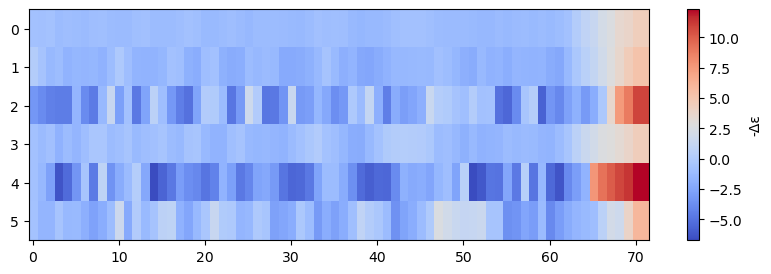

In [38]:
# Plot heatmap
arr = model.conv1(seq_batch[5]).cpu().detach().numpy()

fig, ax = plt.subplots(figsize=(10, 3))

img = ax.imshow(arr, cmap='coolwarm', aspect='auto')
cbar = fig.colorbar(img, ax=ax)
cbar.set_label('-Δε')

plt.show()

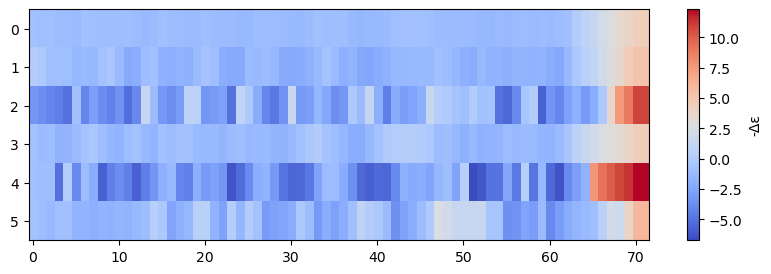

In [43]:
# Plot heatmap
arr = model.conv1(seq_batch[4]).cpu().detach().numpy()

fig, ax = plt.subplots(figsize=(10, 3))

img = ax.imshow(arr, cmap='coolwarm', aspect='auto')
cbar = fig.colorbar(img, ax=ax)
cbar.set_label('-Δε')

plt.show()

In [44]:
y_energy = model.energy(X_test_seq.to(device)).cpu().squeeze(1).detach().numpy()
y_pred = model(X_test_seq, X_test_conds).cpu().squeeze(1).detach().numpy()
y_meas = y_test.cpu().detach().numpy().squeeze(1)

[[1.         0.85493082]
 [0.85493082 1.        ]]
SignificanceResult(statistic=0.8433811915792522, pvalue=0.0)


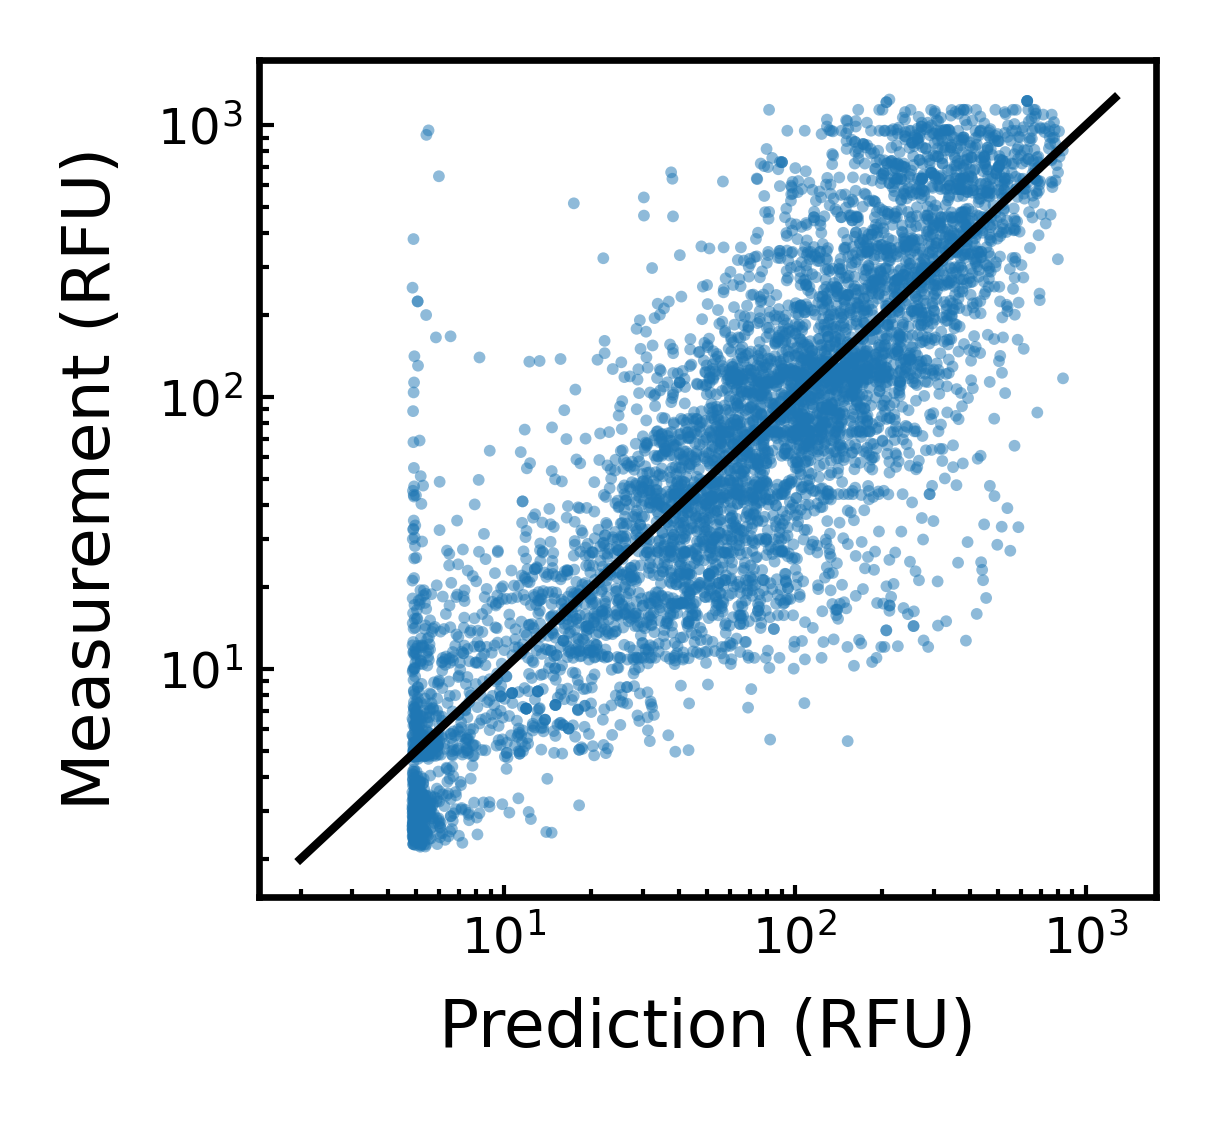

In [66]:
x = y_pred/np.log(10)
y = y_meas/np.log(10)

print(np.corrcoef(x, y))
print(spearmanr(x, y))

fig, ax = plt.subplots(figsize=(54/25.4, 50/25.4), dpi=600)

ax.scatter(x, y, s=2, alpha=0.5, edgecolor='None')
ax.plot([0.3, 3.1], [0.3, 3.1], color='black', lw=1)

sci_ticks(ax, 'x', 6, pad=2)
sci_ticks(ax, 'y', 6, pad=2)

ax.set_xlabel("Prediction (RFU)", fontsize=8)
ax.set_ylabel("Measurement (RFU)", fontsize=8)

plt.tight_layout()
plt.savefig("../figures/CorePromoter.png")
plt.show()

In [60]:
np.mean(np.abs(y-x))

0.2712119

[[1.         0.89046579]
 [0.89046579 1.        ]]
SignificanceResult(statistic=0.865615878113166, pvalue=0.0)


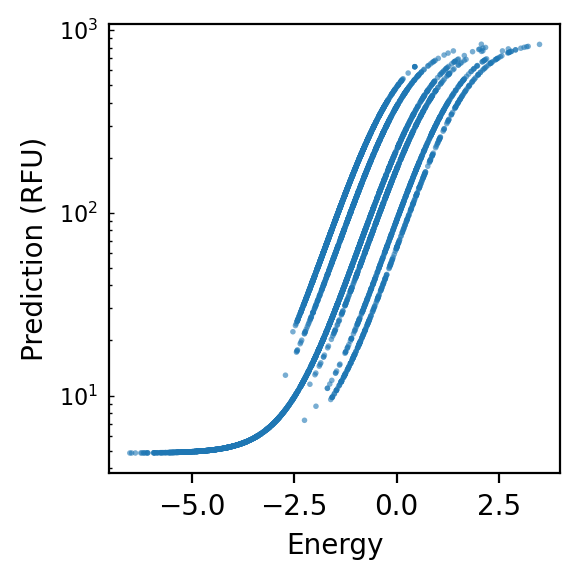

In [46]:
x = y_energy
y = y_pred/np.log(10)

print(np.corrcoef(x, y))
print(spearmanr(x, y))

fig, ax = plt.subplots(figsize=(3, 3), dpi=200)

ax.scatter(x, y, s=4, alpha=0.6, edgecolor='None')
# ax.plot([0.3, 3.5], [0.3, 3.5], color='black', lw=1)

# sci_ticks(ax, 'x', 8)
sci_ticks(ax, 'y', 8)

ax.set_xlabel("Energy", fontsize=10)
ax.set_ylabel("Prediction (RFU)", fontsize=10)

plt.tight_layout()
# plt.savefig("../figures/BoltzNet_Prediction.png")
plt.show()

In [ ]:
df_ProDB = pd.read_csv("../tables_other/PromoterDB.tsv", sep='\t')
df_ProDB = df_ProDB[df_ProDB['category'] == 'active']
# df_ProDB = df_ProDB[df_ProDB['Spacer'].apply(len) == 17]
df_ProDB = df_ProDB.sort_values('activity')
df_ProDB

In [ ]:
# 2. Prepare Features (X) and Targets (y)
sequences = df_ProDB['sequence'].apply(lambda x: x[:-5][-100:])
X_seq = sequences.apply(dna_one_hot)
X_seq = np.array(list(X_seq))

X_seq = torch.tensor(X_seq, dtype=torch.float32)
X_conds = torch.tensor(np.array([[1, 0]]*len(X_seq)), dtype=torch.float32)

y_energy = model.energy(X_seq.to(device)).cpu().squeeze(1).detach().numpy()
# y_pred = model(X_seq.to(device), X_conds.to(device)).cpu().squeeze(1).detach().numpy()
y_meas = np.log(df_ProDB['activity'].values)

In [ ]:
fig, ax = plt.subplots(figsize=(3, 3), dpi=200)

ax.scatter(y_energy, y_meas/np.log(10), s=4, alpha=0.6, edgecolor='None')

# sci_ticks(ax, 'x', 8)
sci_ticks(ax, 'y', 8)

ax.set_xlabel("Binding Energy", fontsize=10)
ax.set_ylabel("Prediction", fontsize=10)

plt.tight_layout()
# plt.savefig("../figures/BoltzNet_Prediction_ProDB.png")
plt.show()

In [ ]:
np.corrcoef(y_energy, y_meas/np.log(10))

In [ ]:
df_10898 = pd.read_csv("../tables_other/Promoter10898.tsv", sep='\t')
# df_10898 = df_10898[df_10898['category'] == 'active']
# df_10898 = df_10898[df_10898['Spacer'].apply(len) == 17]
# df_10898 = df_10898.sort_values('activity')
df_10898 = df_10898[['most_common', 'RNA_exp_average']]
df_10898

In [ ]:
sequences = df_10898['most_common'].apply(lambda x: x[:-20][-100:])
X_seq = sequences.apply(dna_one_hot)
X_seq = np.array(list(X_seq))

X_seq = torch.tensor(X_seq, dtype=torch.float32)
X_conds = torch.tensor(np.array([[1, 0]]*len(X_seq)), dtype=torch.float32)

y_energy = model.energy(X_seq.to(device)).cpu().squeeze(1).detach().numpy()
# y_pred = model(X_seq.to(device), X_conds.to(device)).cpu().squeeze(1).detach().numpy()
y_meas = np.log(df_10898['RNA_exp_average'].values)

In [ ]:
fig, ax = plt.subplots(figsize=(3, 3), dpi=200)

ax.scatter(y_energy, y_meas/np.log(10), s=4, alpha=0.6, edgecolor='None')

# sci_ticks(ax, 'x', 8)
sci_ticks(ax, 'y', 8)

ax.set_xlabel("Binding Energy", fontsize=10)
ax.set_ylabel("Prediction", fontsize=10)

plt.tight_layout()
# plt.savefig("../figures/BoltzNet_Prediction_10898.png")
plt.show()

In [ ]:
np.corrcoef(y_energy, y_meas)

In [ ]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(y_energy, y_meas)
print("Spearman's rho:", round(rho, 3))